# GPT 프롬프트 캐싱 속도 벤치마크 — 200K 컨텍스트 (TTFT + 전체 latency)

**목표**: `gpt-5.4-mini`에서 ~200,000 토큰짜리 긴 대화 컨텍스트를 두고,
프롬프트(KV) 캐시가 **미스(cold)** 일 때와 **히트(warm)** 일 때
- **TTFT** — 첫 토큰까지 지연 (prefill 처리 시간의 근사)
- **전체 응답 latency**

가 각각 얼마나 빨라지는지 측정합니다.

## 동작 원리 / 실험 설계
- OpenAI 프롬프트 캐싱은 **1024 토큰 이상 프리픽스**에 대해 자동 적용됩니다. 동일 프리픽스로 다시 요청하면 캐시가 히트되어 **prefill 단계를 건너뜁니다**.
- `usage.prompt_tokens_details.cached_tokens` 로 실제 캐시 적중 토큰 수를 확인합니다.
- **캐시 미스 강제**: 매 호출마다 system 프리픽스 맨 앞에 유니크 nonce 삽입 → 프리픽스가 매번 달라져 항상 미스. `prompt_cache_key` 도 매번 다르게.
- **캐시 히트 유도**: 완전히 동일한 컨텍스트로 워밍업한 뒤 반복 호출(+ 동일 `prompt_cache_key`).
- 출력은 짧게(기본 32토큰) 고정하고 reasoning은 최소화 → **캐싱이 실제로 단축하는 prefill 구간**의 효과에 집중.

> ⚠️ **주의**
> - 200K 입력 × 여러 회 호출은 **토큰 비용**과 **분당 토큰(TPM) 한도**를 크게 소모합니다. `N_REPEAT` 로 조절하세요.
> - `gpt-5.4-mini` 가 계정에 없으면 첫 호출에서 **404** 가 납니다 — 아래 `MODEL` 변수를 교체하세요.
> - OpenAI 캐시는 수 분만 유지(트래픽 없으면 evict)되므로 MISS→HIT를 **연속 실행**하세요.
> - `REASONING_EFFORT` 지원값은 모델마다 다릅니다(gpt-5.4-mini 는 `none/low/medium/high/xhigh`). 400 이 나면 지원값으로 바꾸거나 파이썬 `None`(파라미터 미전송)으로 두세요.


In [1]:
# === 셋업 & 실험 설정 ===
import os, time, statistics, uuid
from openai import OpenAI

try:
    from dotenv import load_dotenv
    load_dotenv()  # 프로젝트 루트 .env 의 OPENAI_API_KEY 로드
except Exception:
    pass

client = OpenAI()  # OPENAI_API_KEY 는 환경변수에서

# ------- 조절 가능한 설정 -------
MODEL             = "gpt-5.4-mini"      # ← 사용자가 지정. 존재하지 않으면 여기서 교체하세요.
TARGET_TOKENS     = 200_000            # 대화 컨텍스트 목표 크기
MAX_OUTPUT_TOKENS = 32                 # 출력은 짧게 고정 (prefill 캐싱 효과에 집중)
REASONING_EFFORT  = "none"             # reasoning 끔 → prefill 캐싱 효과에 집중. 지원값: none/low/medium/high/xhigh, 또는 파이썬 None(파라미터 미전송)
N_REPEAT          = 5                   # MISS / HIT 각각 반복 횟수
N_WARMUP          = 2                   # 캐시 적재용 워밍업 호출 횟수
CACHE_KEY         = "cache-speed-200k"  # HIT 호출 라우팅 고정용 prompt_cache_key

# ------- 단가 ($ / 1M tokens) -------
# 출처: 웹검색 2026-07 기준 gpt-5.4-mini. ⚠️ 요금은 변동되니 OpenAI 공식 pricing 으로 재확인하세요.
PRICE_INPUT        = 0.75    # uncached 입력
PRICE_CACHED_INPUT = 0.075   # cached 입력 (약 90% 할인)
PRICE_OUTPUT       = 4.50    # 출력

def calc_cost(prompt_tokens, cached, completion_tokens):
    uncached = (prompt_tokens or 0) - (cached or 0)
    return (uncached * PRICE_INPUT
            + (cached or 0) * PRICE_CACHED_INPUT
            + (completion_tokens or 0) * PRICE_OUTPUT) / 1_000_000

print(f"모델: {MODEL} | 목표 토큰: {TARGET_TOKENS:,} | 반복: {N_REPEAT} | 출력한도: {MAX_OUTPUT_TOKENS}")
print(f"단가($/1M): in {PRICE_INPUT} | cached-in {PRICE_CACHED_INPUT} | out {PRICE_OUTPUT}")


모델: gpt-5.4-mini | 목표 토큰: 200,000 | 반복: 5 | 출력한도: 32
단가($/1M): in 0.75 | cached-in 0.075 | out 4.5


In [2]:
# === 토큰 카운터 (tiktoken 있으면 정밀, 없으면 근사) ===
# tiktoken 이 없으면:  %pip install tiktoken  후 커널 재시작하면 정밀해집니다.
# 근사를 쓰더라도 아래에서 실제 토큰 수는 API usage 로 실측 리포트됩니다.
try:
    import tiktoken
    try:
        _enc = tiktoken.encoding_for_model(MODEL)
    except KeyError:
        _enc = tiktoken.get_encoding("o200k_base")  # gpt-4o/5 계열 인코딩
    def count_tokens(s: str) -> int:
        return len(_enc.encode(s))
    HAVE_TIKTOKEN = True
except Exception:
    def count_tokens(s: str) -> int:
        return max(1, round(len(s) / 3.7))  # 영어 기준 대략치
    HAVE_TIKTOKEN = False

print("tiktoken 정밀 카운트:", HAVE_TIKTOKEN)


tiktoken 정밀 카운트: False


In [3]:
# === 200K 대화 컨텍스트 생성 (합성 멀티턴 Q&A) ===
SYSTEM_BASE = (
    "You are a senior software engineer helping with a long, ongoing technical "
    "design discussion about distributed systems. Keep the final answer very brief."
)

_Q = (
    "Question {i}: In our distributed order-processing service we occasionally see "
    "duplicate side effects when a consumer redelivers a message. Walk me through how "
    "idempotency keys, an inbox table, and exactly-once semantics interact, and where "
    "the usual mistakes are (batch {i})."
)
_A = (
    "Answer {i}: Redelivery is expected under at-least-once delivery, so the consumer "
    "must be idempotent. Derive an idempotency key from the message id and insert it into "
    "an inbox table inside the SAME transaction that applies the side effect; on redelivery "
    "the unique constraint short-circuits the duplicate. True exactly-once across a network "
    "is impossible, so you approximate it with at-least-once delivery plus idempotent effects. "
    "Common mistakes: committing the inbox row in a separate transaction from the effect, "
    "using a non-deterministic key, and forgetting that outbound publishes also need the "
    "outbox pattern to avoid dual-write races (batch {i})."
)

def build_conversation(target_tokens: int):
    messages = [{"role": "system", "content": SYSTEM_BASE}]
    total = count_tokens(SYSTEM_BASE)
    i = 0
    while total < target_tokens - 200:          # 최종 질문 몫으로 여유
        u = _Q.format(i=i)
        a = _A.format(i=i)
        messages.append({"role": "user", "content": u})
        messages.append({"role": "assistant", "content": a})
        total += count_tokens(u) + count_tokens(a)
        i += 1
    # 캐시 프리픽스에 포함되는 '최종 질문' — 매 호출 동일해야 히트됨
    messages.append({
        "role": "user",
        "content": "Given everything above, state the single most important rule in one short sentence.",
    })
    return messages, total

CONV, approx_tokens = build_conversation(TARGET_TOKENS)
print(f"메시지 수: {len(CONV):,} | 근사 토큰: {approx_tokens:,}  (실측은 아래 첫 호출 usage 로 확인)")


메시지 수: 1,602 | 근사 토큰: 200,021  (실측은 아래 첫 호출 usage 로 확인)


In [4]:
# === 측정 유틸: 스트리밍으로 TTFT + 전체 latency + cached_tokens ===
def timed_call(messages, *, unique: bool):
    """unique=True 이면 매번 유니크 프리픽스로 캐시 MISS 강제, False 이면 동일 프리픽스로 HIT 유도."""
    msgs = messages
    nonce = None
    if unique:
        nonce = uuid.uuid4().hex
        head = messages[0]
        # system 프리픽스 맨 앞에 nonce 삽입 → prefix 전체가 매번 달라짐
        msgs = [{**head, "content": f"[nonce-{nonce}] " + head["content"]}] + messages[1:]

    kwargs = dict(
        model=MODEL,
        messages=msgs,
        max_completion_tokens=MAX_OUTPUT_TOKENS,
        stream=True,
        stream_options={"include_usage": True},
    )
    if REASONING_EFFORT:
        kwargs["reasoning_effort"] = REASONING_EFFORT
    # HIT 는 동일 key 로 라우팅 고정, MISS 는 매번 다른 key
    kwargs["prompt_cache_key"] = ("miss-" + nonce) if unique else CACHE_KEY

    t0 = time.perf_counter()
    ttft = None
    usage = None
    stream = client.chat.completions.create(**kwargs)
    for chunk in stream:
        if ttft is None and chunk.choices:      # 첫 스트림 이벤트 도착 = prefill 종료 근사
            ttft = time.perf_counter() - t0
        u = getattr(chunk, "usage", None)
        if u is not None:
            usage = u
    total = time.perf_counter() - t0
    if ttft is None:
        ttft = total

    cached, ptoks, ctoks = 0, None, None
    if usage is not None:
        ptoks = usage.prompt_tokens
        ctoks = getattr(usage, "completion_tokens", None)
        ptd = getattr(usage, "prompt_tokens_details", None)
        if ptd is not None:
            cached = getattr(ptd, "cached_tokens", 0) or 0
    cost = calc_cost(ptoks, cached, ctoks)
    return {"ttft": ttft, "total": total, "cached": cached,
            "prompt_tokens": ptoks, "completion_tokens": ctoks, "cost": cost}


In [5]:
# === 워밍업: 캐시 적재 + 실제 prompt_tokens 실측 ===
print("워밍업(캐시 적재) 중...")
first = timed_call(CONV, unique=False)
print(f"  1차: prompt_tokens={first['prompt_tokens']:,} | cached={first['cached']:,} "
      f"| TTFT={first['ttft']*1000:.0f}ms total={first['total']*1000:.0f}ms | cost=${first['cost']:.4f}")
if first["prompt_tokens"]:
    print(f"  → 실측 입력 토큰 ≈ {first['prompt_tokens']:,} "
          f"(목표 {TARGET_TOKENS:,}. 차이 크면 TARGET_TOKENS 조정)")

for w in range(max(0, N_WARMUP - 1)):
    r = timed_call(CONV, unique=False)
    print(f"  워밍업 {w+2}: cached={r['cached']:,} TTFT={r['ttft']*1000:.0f}ms total={r['total']*1000:.0f}ms")


워밍업(캐시 적재) 중...
  1차: prompt_tokens=162,451 | cached=162,048 | TTFT=6536ms total=6703ms | cost=$0.0126
  → 실측 입력 토큰 ≈ 162,451 (목표 200,000. 차이 크면 TARGET_TOKENS 조정)
  워밍업 2: cached=162,048 TTFT=4312ms total=4730ms


In [6]:
# === 벤치마크: MISS(cold) vs HIT(warm) ===
def bench(label, unique, n):
    rows = []
    for k in range(n):
        r = timed_call(CONV, unique=unique)
        rows.append(r)
        print(f"  [{label}] {k+1}/{n}: TTFT={r['ttft']*1000:7.0f}ms  "
              f"total={r['total']*1000:7.0f}ms  cached={r['cached']:,}  cost=${r['cost']:.4f}")
    return rows

print("=== 캐시 MISS (cold, 매 호출 유니크 프리픽스) ===")
miss = bench("MISS", unique=True, n=N_REPEAT)
print("=== 캐시 HIT (warm, 동일 프리픽스 반복) ===")
hit = bench("HIT", unique=False, n=N_REPEAT)


=== 캐시 MISS (cold, 매 호출 유니크 프리픽스) ===
  [MISS] 1/5: TTFT=   4397ms  total=   4686ms  cached=0  cost=$0.1219
  [MISS] 2/5: TTFT=   5944ms  total=   6300ms  cached=0  cost=$0.1220
  [MISS] 3/5: TTFT=   4663ms  total=   4908ms  cached=0  cost=$0.1219
  [MISS] 4/5: TTFT=   4623ms  total=   4987ms  cached=0  cost=$0.1220
  [MISS] 5/5: TTFT=   7009ms  total=   7264ms  cached=0  cost=$0.1219
=== 캐시 HIT (warm, 동일 프리픽스 반복) ===
  [HIT] 1/5: TTFT=   3689ms  total=   4009ms  cached=162,048  cost=$0.0126
  [HIT] 2/5: TTFT=   5394ms  total=   5516ms  cached=162,048  cost=$0.0125
  [HIT] 3/5: TTFT=   4037ms  total=   4242ms  cached=162,048  cost=$0.0125
  [HIT] 4/5: TTFT=   3449ms  total=   3717ms  cached=162,048  cost=$0.0126
  [HIT] 5/5: TTFT=   4621ms  total=   4707ms  cached=162,048  cost=$0.0125


In [7]:
# === 결과 집계 & 개선율 ===
def stat(rows, key):
    xs = [r[key] for r in rows]
    return {"mean": statistics.mean(xs), "p50": statistics.median(xs), "min": min(xs)}

def ms(x): return f"{x*1000:.0f}"

print(f"모델 {MODEL} | 반복 {N_REPEAT}회 | 입력≈{first['prompt_tokens'] or approx_tokens:,} tok\n")
for name, key in [("TTFT (첫 토큰)", "ttft"), ("전체 latency", "total")]:
    m, h = stat(miss, key), stat(hit, key)
    imp = (1 - h["mean"] / m["mean"]) * 100 if m["mean"] else 0
    speedup = (m["mean"] / h["mean"]) if h["mean"] else float("inf")
    print(f"[{name}]")
    print(f"  MISS  mean {ms(m['mean'])}ms  p50 {ms(m['p50'])}ms  min {ms(m['min'])}ms")
    print(f"  HIT   mean {ms(h['mean'])}ms  p50 {ms(h['p50'])}ms  min {ms(h['min'])}ms")
    print(f"  -> 개선: {imp:5.1f}% 단축  ({speedup:.2f}x 빠름)\n")

avg_cached_hit  = statistics.mean([r["cached"] for r in hit])
avg_cached_miss = statistics.mean([r["cached"] for r in miss])
_pt = [r["prompt_tokens"] for r in hit if r["prompt_tokens"]]
avg_ptoks = statistics.mean(_pt) if _pt else (first["prompt_tokens"] or approx_tokens)
print(f"cached_tokens 평균 — HIT: {avg_cached_hit:,.0f} / MISS: {avg_cached_miss:,.0f} "
      f"(전체 prompt_tokens ≈ {avg_ptoks:,.0f})")
print(f"HIT 캐시 적중률 ≈ {avg_cached_hit / avg_ptoks:.0%}" if avg_ptoks else "")
if avg_cached_hit < 1024:
    print("⚠️ HIT cached_tokens 가 0 근처입니다 — 캐시 미적재/evict 가능. MISS→HIT 를 연속 재실행하세요.")

# --- 비용 ---
miss_cost = statistics.mean([r["cost"] for r in miss])
hit_cost  = statistics.mean([r["cost"] for r in hit])
save_pct  = (1 - hit_cost / miss_cost) * 100 if miss_cost else 0
run_total = first["cost"] + sum(r["cost"] for r in miss) + sum(r["cost"] for r in hit)
print(f"\n[비용] 호출당 평균 — MISS ${miss_cost:.4f} / HIT ${hit_cost:.4f}  →  {save_pct:.1f}% 절감")
print(f"  이번 벤치 총비용 ≈ ${run_total:.4f}  (워밍업 1차 + MISS {N_REPEAT} + HIT {N_REPEAT}, 워밍업 추가분 제외)")


모델 gpt-5.4-mini | 반복 5회 | 입력≈162,451 tok

[TTFT (첫 토큰)]
  MISS  mean 5327ms  p50 4663ms  min 4397ms
  HIT   mean 4238ms  p50 4037ms  min 3449ms
  -> 개선:  20.5% 단축  (1.26x 빠름)

[전체 latency]
  MISS  mean 5629ms  p50 4987ms  min 4686ms
  HIT   mean 4438ms  p50 4242ms  min 3717ms
  -> 개선:  21.2% 단축  (1.27x 빠름)

cached_tokens 평균 — HIT: 162,048 / MISS: 0 (전체 prompt_tokens ≈ 162,451)
HIT 캐시 적중률 ≈ 100%

[비용] 호출당 평균 — MISS $0.1219 / HIT $0.0125  →  89.7% 절감
  이번 벤치 총비용 ≈ $0.6850  (워밍업 1차 + MISS 5 + HIT 5, 워밍업 추가분 제외)


Matplotlib is building the font cache; this may take a moment.


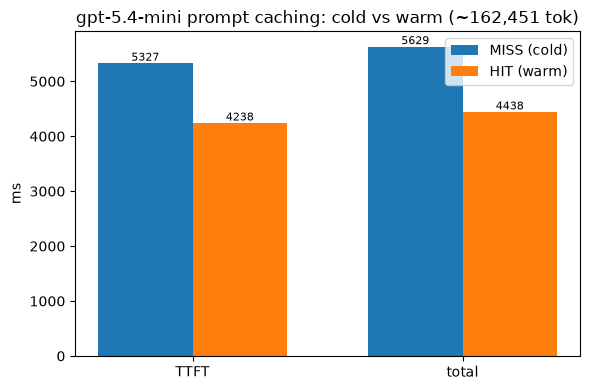

In [8]:
# === (선택) 막대그래프 시각화 — matplotlib 있으면 ===
try:
    import matplotlib.pyplot as plt
    labels   = ["TTFT", "total"]
    miss_ms  = [stat(miss, "ttft")["mean"] * 1000, stat(miss, "total")["mean"] * 1000]
    hit_ms   = [stat(hit, "ttft")["mean"] * 1000,  stat(hit, "total")["mean"] * 1000]
    xs = range(len(labels)); w = 0.35
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar([x - w/2 for x in xs], miss_ms, w, label="MISS (cold)")
    ax.bar([x + w/2 for x in xs], hit_ms,  w, label="HIT (warm)")
    ax.set_ylabel("ms"); ax.set_xticks(list(xs)); ax.set_xticklabels(labels)
    ax.set_title(f"{MODEL} prompt caching: cold vs warm (~{(first['prompt_tokens'] or approx_tokens):,} tok)")
    ax.legend()
    for i, (mv, hv) in enumerate(zip(miss_ms, hit_ms)):
        ax.text(i - w/2, mv, f"{mv:.0f}", ha="center", va="bottom", fontsize=8)
        ax.text(i + w/2, hv, f"{hv:.0f}", ha="center", va="bottom", fontsize=8)
    plt.tight_layout(); plt.show()
except Exception as e:
    print("시각화 건너뜀:", e)


## 결과 해석 가이드

- **TTFT 개선율 > 전체 latency 개선율** 이 정상입니다. 프롬프트 캐싱은 입력을 처리하는 **prefill 구간만** 단축하고, 출력 토큰을 만드는 **디코딩 구간은 그대로**이기 때문입니다. 그래서 출력을 짧게(`MAX_OUTPUT_TOKENS`) 고정할수록 캐싱 효과가 total 에서도 크게 드러납니다.
- **`cached_tokens` 확인**: HIT 호출의 `cached_tokens` 가 전체 `prompt_tokens` 에 근접(수만~십수만)해야 진짜 히트입니다. MISS 호출은 0 에 가까워야 합니다.
- **cached_tokens 가 0 이면**: ① 캐시가 아직 적재 안 됨(워밍업 직후) ② 수 분 방치로 evict ③ 프리픽스가 1024 토큰 미만 ④ 해당 모델이 캐싱 미지원 — 이 경우 MISS→HIT 셀을 **연속으로 재실행**하세요.
- **변동성**: 네트워크/서버 부하로 TTFT 는 흔들립니다. `N_REPEAT` 를 늘리고 `p50`/`min` 을 함께 보세요. 특히 `min` 은 이론적 최선의 캐싱 이득에 가장 근접합니다.

### 비용 · 한도 메모
- 이 벤치마크는 `(N_WARMUP + 2*N_REPEAT)` 회 × ~200K 입력 토큰을 호출합니다. HIT 분은 캐시 할인이 적용되지만 MISS 분은 전액 과금됩니다. 먼저 `TARGET_TOKENS`/`N_REPEAT` 를 작게 낮춰 파이프라인이 도는지 확인한 뒤 200K 로 올리는 것을 권장합니다.
- 200K 단발 요청은 계정의 **분당 토큰(TPM)** 한도를 넘길 수 있습니다. 429 가 나면 한도 상향 또는 `TARGET_TOKENS` 하향이 필요합니다.
